<a href="https://colab.research.google.com/github/shuangquan-li-con/ECON5200-37499-Applied-Data-Analytics-in-Economics/blob/main/Checkpoint_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.Causal question: Does the New Jersey minimum wage increase cause a change in fast-food restaurant employment relative to Pennsylvania?

2.Identification strategy: Difference-in-Difference(DiD)

3.Key assumptions:In the absence of the minimum wage increase,employment in New Jersey and Pennsylvania fast-food restaurants would have followed similar trends over time.

4.Why prediction-only is insufficient:A prediction-only model can describe correlations between wages and employment, but it cannot isolate the causal effect of the policy change. Since the goal is to understand what happens to employment if the minimum wage is increased, a causal design is required.

5.Dataset identified with source, N, treatment/outcome/control variables: The dataset used in this analysis comes from the New Jersey–Pennsylvania fast-food restaurant study conducted by David Card. The dataset contains information on fast-food restaurants in New Jersey (treated group) and Pennsylvania (control group) before and after a minimum wage increase.The dataset includes 410 observations, where each observation corresponds to a fast-food restaurant. Treatment variable: treated — equals 1 if the restaurant is located in New Jersey (affected by the minimum wage increase), and 0 if located in Pennsylvania. Outcome variable:employment — measured as full-time equivalent (FTE) employment,  constructed as: FTE = full-time employees + managers + 0.5 × part-time employees. Time variable: post — equals 1 for the period after the policy change, and 0 for the period before. Key interaction term: did — interaction between treated and post, capturing the causal effect of the policy.
 Control variables (optional in checkpoint stage):  Wage variables such as wage_st and wage_st2 can be used to explore differences across groups.

In [10]:
# 6.Data loaded and described
import pandas as pd

df = pd.read_csv(
    "/content/njmin_clean.csv",
  )

df.shape

(410, 48)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 49 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sheet       410 non-null    int64  
 1   chain       410 non-null    int64  
 2   co_owned    410 non-null    int64  
 3   state       410 non-null    int64  
 4   southj      410 non-null    int64  
 5   centralj    410 non-null    int64  
 6   northj      410 non-null    int64  
 7   pa1         410 non-null    int64  
 8   pa2         410 non-null    int64  
 9   shore       410 non-null    int64  
 10  ncalls      410 non-null    int64  
 11  empft       404 non-null    float64
 12  emppt       406 non-null    float64
 13  nmgrs       404 non-null    float64
 14  wage_st     390 non-null    float64
 15  inctime     410 non-null    object 
 16  firstinc    410 non-null    object 
 17  bonus       410 non-null    int64  
 18  pctaff      410 non-null    object 
 19  meals       410 non-null    i

The dataset is loaded from the original raw data file (public.dat) provided in the Card and Krueger study. Since the dataset is stored as a fixed-width text file, it is parsed using whitespace separation and then assigned column names based on the codebook.

Each observation represents a fast-food restaurant. The dataset contains information on employment levels and wages before and after the minimum wage increase.

Key variables used in this analysis include:

state: indicates whether the restaurant is located in New Jersey (treated) or Pennsylvania (control)
empft, emppt, nmgrs: employment components before the policy
empft2, emppt2, nmgrs2: employment components after the policy
wage_st, wage_st2: starting wages before and after the policy

These variables are used to construct full-time equivalent employment (FTE) before and after the policy change.

In [12]:
#7.Balance checks between treated/untreated groups
df_before = df.copy()
df_before = df_before[["state", "fte_before", "wage_st"]]
df_before.groupby("state")[["fte_before", "wage_st"]].mean()

,fte_before,wage_st
state,,
0,23.331169,4.630132
1,20.439408,4.612134


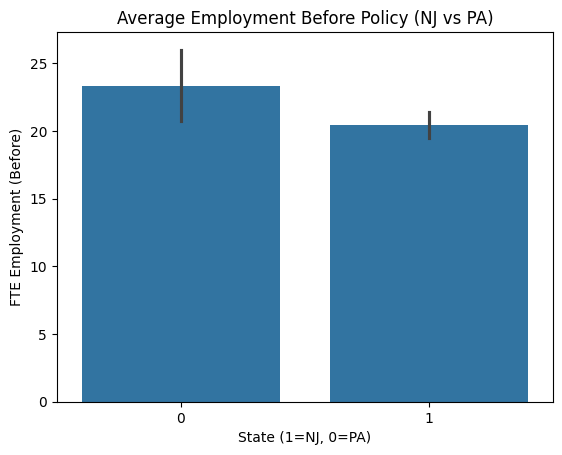

In [37]:
#8. 3 visualizations with intrepretations
# Visualization 1: Balance Check
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=df_before, x="state", y="fte_before")
plt.title("Average Employment Before Policy (NJ vs PA)")
plt.xlabel("State (1=NJ, 0=PA)")
plt.ylabel("FTE Employment (Before)")
plt.show()

Balance Check

Before the policy change, we compare employment and wages between New Jersey (treated group) and Pennsylvania (control group).

The average employment (FTE) is 23.33 in Pennsylvania and 20.44 in New Jersey, indicating that employment levels in New Jersey are slightly lower than in Pennsylvania before the policy change. However, the difference is not very large.

The average starting wage is 4.63 in Pennsylvania and 4.61 in New Jersey, which suggests that wages are very similar across the two groups before the policy.

Overall, the two groups appear to be reasonably comparable before the policy change，supporting the validity of the DiD approach.. While there are some differences in employment levels, the Difference-in-Differences approach accounts for these baseline differences by focusing on changes over time rather than levels.


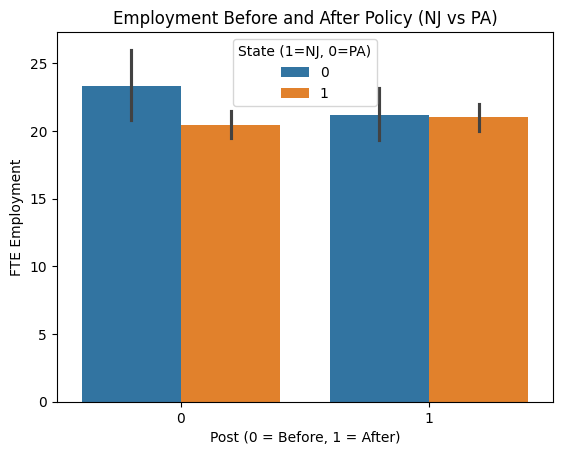

In [38]:
#Visualization 2: Employment Before and After
import seaborn as sns
df_before = df.copy()
df_before["post"] = 0
df_before["employment"] = df_before["fte_before"]

df_after = df.copy()
df_after["post"] = 1
df_after["employment"] = df_after["fte_after"]

df_long = pd.concat([df_before, df_after], ignore_index=True)

sns.barplot(data=df_long, x="post", y="employment", hue="state")
plt.title("Employment Before and After Policy (NJ vs PA)")
plt.xlabel("Post (0 = Before, 1 = After)")
plt.ylabel("FTE Employment")
plt.legend(title="State (1=NJ, 0=PA)")
plt.show()

Visualization: Employment Before and After

This figure compares average employment levels before and after the policy change for New Jersey and Pennsylvania.

We observe how employment evolves over time in both groups. The key insight is whether employment changes differently in New Jersey relative to Pennsylvania after the policy change.

A divergence in trends between the two groups after the policy would suggest a potential causal effect of the minimum wage increase.

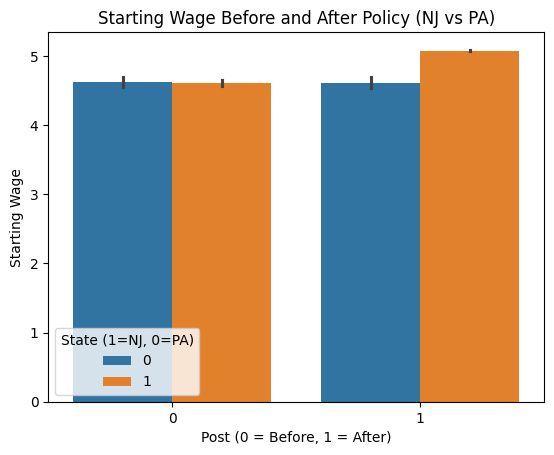

In [39]:
#Visualization 3: Wage Before and After
import matplotlib.pyplot as plt

df_before = df.copy()
df_before["post"] = 0
df_before["wage"] = df_before["wage_st"]

df_after = df.copy()
df_after["post"] = 1
df_after["wage"] = df_after["wage_st2"]

df_wage = pd.concat([df_before, df_after], ignore_index=True)

sns.barplot(data=df_wage, x="post", y="wage", hue="state")
plt.title("Starting Wage Before and After Policy (NJ vs PA)")
plt.xlabel("Post (0 = Before, 1 = After)")
plt.ylabel("Starting Wage")
plt.legend(title="State (1=NJ, 0=PA)")
plt.show()

Visualization: Wage Before and After

This figure shows the change in wages before and after the policy for both New Jersey and Pennsylvania.

We expect wages in New Jersey to increase after the policy change, while wages in Pennsylvania remain relatively stable.

This provides supporting evidence that the policy intervention (minimum wage increase) was effectively implemented in the treated group.

In [27]:
#9 Missing data assessed
df.isna().sum()

,0
sheet,0
chain,0
co_owned,0
state,0
southj,0
centralj,0
northj,0
pa1,0
pa2,0
shore,0


In [28]:
df.isna().mean()

,0
sheet,0.000000
chain,0.000000
co_owned,0.000000
state,0.000000
southj,0.000000
centralj,0.000000
northj,0.000000
pa1,0.000000
pa2,0.000000
shore,0.000000


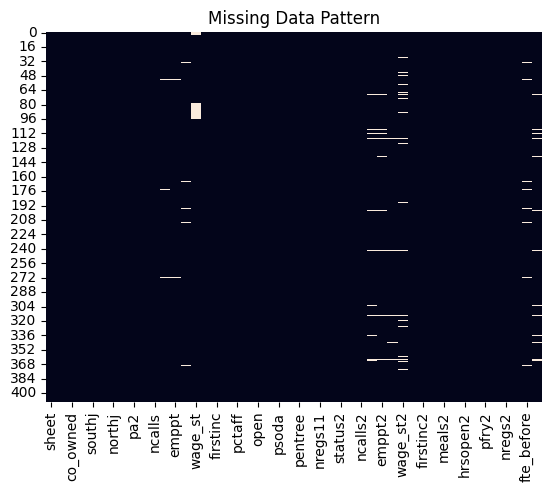

In [29]:
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Data Pattern")
plt.show()

Missing Data Assessment

The heatmap above shows the pattern of missing values across the dataset, where dark areas represent observed data and lighter areas indicate missing values.

Overall, most of the dataset is complete, with only a small number of scattered missing values across certain variables. There is no strong clustering of missing data in specific observations or variables, suggesting that missingness is relatively limited and does not follow a clear systematic pattern.

Although some variables—particularly those related to post-treatment measures—contain missing values, the overall proportion is low. Therefore, it is unlikely that missing data will significantly bias the analysis.

In this study, observations with missing values in key variables are effectively excluded from calculations, and the impact of missing data is expected to be minimal.

In [30]:
#10. Naive estimate computed (OLS or simple comparison)
df.groupby("state")["fte_after"].mean()

,fte_after
state,
0,21.165584
1,21.027429


In [31]:
naive = df.groupby("state")["fte_after"].mean().diff().iloc[-1]
naive

np.float64(-0.13815494849977483)

In [32]:
import statsmodels.formula.api as smf

model = smf.ols("fte_after ~ state", data=df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              fte_after   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                   0.01428
Date:                Sun, 19 Apr 2026   Prob (F-statistic):              0.905
Time:                        02:55:39   Log-Likelihood:                -1435.6
No. Observations:                 396   AIC:                             2875.
Df Residuals:                     394   BIC:                             2883.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     21.1656      1.038     20.397      0.000      19.125      23.206
state         -0.1382      1.156     -0.119      0.905      -2.411       2.135
==============================================================================
Omnibus:                       44.985   Durbin-Watson:                   1.769
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               71.204
Skew:                           0.726   Prob(JB):                     3.45e-16
Kurtosis:                       4.486   Cond. No.                         4.33
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Naive Estimate

We compute a naive estimate of the policy effect by comparing average employment levels between New Jersey (treated) and Pennsylvania (control) after the policy change.

The average employment (FTE) after the policy is 21.17 in Pennsylvania and 21.03 in New Jersey, resulting in a difference of approximately -0.14.

This suggests that, based on a simple comparison, employment in New Jersey is slightly lower than in Pennsylvania after the policy change.

However, this estimate is naive because it does not account for pre-existing differences between the two groups or changes over time. As a result, it is likely to be biased.



11.Brief note on expected direction of bias in naive estimate：
Expected Bias

Before the policy change, employment levels in New Jersey were already lower than in Pennsylvania. Ignoring this baseline difference may lead to a biased estimate of the treatment effect.

Specifically, the naive estimate likely underestimates the true effect of the policy, since it does not account for the fact that New Jersey started from a lower employment level.

This highlights the importance of using a Difference-in-Differences approach, which compares changes over time rather than simple differences in levels.

In [33]:
#12.At least started causal estimation (even if preliminary)

df["treated"] = df["state"]

df_before = df.copy()
df_before["post"] = 0
df_before["employment"] = df_before["fte_before"]

df_after = df.copy()
df_after["post"] = 1
df_after["employment"] = df_after["fte_after"]

df_long = pd.concat([df_before, df_after], ignore_index=True)


df_long["did"] = df_long["treated"] * df_long["post"]

In [34]:
import statsmodels.formula.api as smf

model_did = smf.ols(
    "employment ~ treated + post + did",
    data=df_long
).fit()

model_did.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             employment   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.964
Date:                Sun, 19 Apr 2026   Prob (F-statistic):              0.118
Time:                        03:02:03   Log-Likelihood:                -2904.2
No. Observations:                 794   AIC:                             5816.
Df Residuals:                     790   BIC:                             5835.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.3312      1.072     21.767      0.000      21.227      25.435
treated       -2.8918      1.194     -2.423      0.016      -5.235      -0.549
post          -2.1656      1.516     -1.429      0.154      -5.141       0.810
did            2.7536      1.688      1.631      0.103      -0.561       6.068
==============================================================================
Omnibus:                      218.742   Durbin-Watson:                   1.840
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              804.488
Skew:                           1.268   Prob(JB):                    2.03e-175
Kurtosis:                       7.229   Cond. No.                         11.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Preliminary Causal Estimation (Difference-in-Differences)

We estimate the causal effect of the minimum wage increase on employment using a Difference-in-Differences (DiD) regression:

Employment = β₀ + β₁ Treated + β₂ Post + β₃ (Treated × Post) + ε

The coefficient on the interaction term (Treated × Post) captures the causal effect of the policy.

From the regression results, the estimated coefficient on the interaction term (did) is approximately 2.75, suggesting that employment in New Jersey increased by about 2.75 full-time equivalent workers relative to Pennsylvania after the policy change.

However, the estimate is not statistically significant (p-value ≈ 0.10), indicating that we cannot confidently reject the null hypothesis of no effect at conventional significance levels.
The Difference-in-Differences approach improves upon the naive estimate by controlling for baseline differences between groups and common time trends.
The DiD estimate differs substantially from the naive estimate, which incorrectly suggested a near-zero or slightly negative effect. This highlights the importance of accounting for baseline differences and time trends.